In [65]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tiktoken

## 모델 설정

In [66]:
# GPT-2 모델 설정값
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 어휘사전 크기
    "context_length": 256,  # 문맥 길이
    "emb_dim": 768,         # 임베딩 차원
    "n_heads": 12,          # 어텐션 헤드 개수
    "n_layers": 12,         # 층 개수
    "drop_rate": 0.1,       # 드롭아웃 비율
    "qkv_bias": False       # 쿼리, 키, 값 계산을 위한 편향
}

In [67]:
# Multi Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out은 num_heads로 나누어 떨어져야 합니다."

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)    # Q = x @ W_query.T
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)      # K = x @ W_key.T 
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)    # V = x @ W_value.T 

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # (b, tokens, heads, head_dim) -> (b, heads, tokens, head_dim)
        queries = queries.transpose(1, 2) 
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # (b, heads, tokens, head_dim) @ (b, heads, head_dim, tokens) -> (b, heads, tokens, tokens)
        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # (b, heads, tokens, tokens) @ (b, heads, tokens, head_dim) -> T -> (b, tokens, heads, head_dim)
        context_vecs = (attn_weights @ values).transpose(1, 2)
        # (b, tokens, heads, head_dim) -> (b, tokens, d_out)
        context_vecs = context_vecs.contiguous().view(b, num_tokens, self.d_out)

        # head 간 정보를 섞는 단계
        context_vecs = self.out_proj(context_vecs)
        return context_vecs

In [68]:
# Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        # y = \gamma \hat{x} + \beta
        return self.scale * norm_x + self.shift

In [69]:
# Feed Forward
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [70]:
# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(p=cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [71]:
# GPT Model
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

## 데이터 준비

In [72]:
# 데이터셋 로드 (소설 The Verdict)
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()


tokenizer = tiktoken.get_encoding("gpt2")

# 문자와 토큰 수를 확인
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"문자 수: {total_characters}")       # 문자 수: 20479
print(f"토큰 수: {total_tokens}")           # 토큰 수: 5145

문자 수: 20479
토큰 수: 5145


In [73]:
# Dataset
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

# DataLoader
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

In [74]:
# 데이터 분할과 로딩을 구현하기
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print(f"훈련 데이터 로더:")
for x, y in train_loader:
    print(x.shape, y.shape)

print(f"\n검증 데이터 로더")
for x, y in val_loader:
    print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더
torch.Size([2, 256]) torch.Size([2, 256])


## 텍스트 생성

In [75]:
# 모델이 새로운 토큰들로 토큰 IDs를 반환
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [76]:
# 텍스트 조각(start_context)을 입력으로 받아 토큰 ID로 변환하고 LLM에 주입하여 샘플 텍스트를 생성
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

## 모델 평가

In [77]:
# 단일 배치에 대한 손실 계산
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


# 모든 배치에 대한 손실 계산
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

# 모델 평가
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()
    return train_loss, val_loss

In [78]:
# 훈련 세트 손실과 검증 세트 손실을 나란히 보여주는 간단한 그래프를 작성
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

## 모델 훈련

In [79]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch: {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실: {train_loss:.3f}, Tokens:{tokens_seen}"
                      f"검증 손실 {val_loss:.3f}, Tokens:{tokens_seen}")

        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen

In [80]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

In [81]:
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs,
    eval_freq=5, eval_iter=5, start_context="Every effor moves you", tokenizer=tokenizer
)

Epoch: 1 (Step 000000): 훈련 손실: 9.781, Tokens:512검증 손실 9.933, Tokens:512
Epoch: 1 (Step 000005): 훈련 손실: 8.111, Tokens:3072검증 손실 8.339, Tokens:3072
Every effor moves you,,,,,,,,,,,.                                      
Epoch: 2 (Step 000010): 훈련 손실: 6.661, Tokens:5632검증 손실 7.048, Tokens:5632
Epoch: 2 (Step 000015): 훈련 손실: 5.961, Tokens:8192검증 손실 6.616, Tokens:8192
Every effor moves you, and, and, and, and,, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and, and
Epoch: 3 (Step 000020): 훈련 손실: 5.723, Tokens:10752검증 손실 6.598, Tokens:10752
Epoch: 3 (Step 000025): 훈련 손실: 5.204, Tokens:13312검증 손실 6.351, Tokens:13312
Every effor moves you--I, and I had been, and, and I had. Gis, and I had been, and I had to to the the of the the of the, and I had been, and, and I had to to the of the
Epoch: 4 (Step 000030): 훈련 손실: 4.420, Tokens:15872검증 손실 6.279, Tokens:15872
Epoch: 4 (Step 000035): 훈련 손실: 4.071, Tokens:18432검증 손실 6.226, Tokens:18432
Every effor move

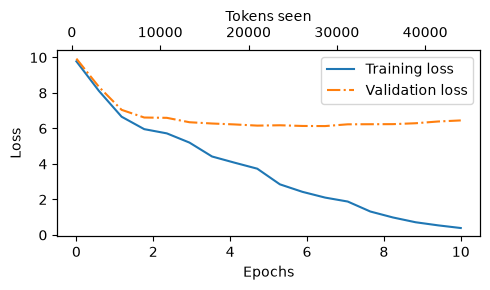

In [82]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 디코딩 전략

In [83]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model, 
    idx=text_to_token_ids("Every effor moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(f"출력 테스트:\n{token_ids_to_text(token_ids, tokenizer)}")

출력 테스트:
Every effor moves you know; and in spite of, his pictures--so handsome, so charming, so disarming, that one longed to


In [84]:
# 확률적 샘플링을 구체적인 예를 들어 설명하기 위해 다음 토큰 생성 과정을 매우 작은 어휘사전으로 설명
vocab = {
    "closer": 0,
    "every": 1, 
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k  for k, v in vocab.items()}

# LLM이 시작 문맥으로 "every effort moves you"를 받고 다음과 같은 로짓을 생성 헀다고 가정
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
print(f"probas:\n{probas}\n")
next_token_id = int(torch.argmax(probas).item())
print(f"next_token_id: {next_token_id}")
print(f"vocab with argmax: {inverse_vocab[next_token_id]}\n")

# 확률적 샘플링 과정을 구현하기 위해 argmax를 파이토치의 multinominal 함수로 바꿀 수 있다.
torch.manual_seed(123)
next_token_id = int(torch.multinomial(
        # input: Tensor,
        input=probas,
        # num_samples: int | SymInt,
        num_samples=1
        # replacement: bool = False,
        # *,
        # generator: Generator | None = None,
        # out: Tensor | None = None
).item())
print(f"multinomial next_token_id: {next_token_id}")
print(f"vocab with multinomial: {inverse_vocab[next_token_id]}\n")

# 설명을 위해 샘플링을 1,000번 수행하는 함수를 만들어보자
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
              for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    print(sampled_ids)
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

probas:
tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

next_token_id: 3
vocab with argmax: forward

multinomial next_token_id: 3
vocab with multinomial: forward

tensor([ 73,   0,   0, 582,   2,   0,   0, 343])
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


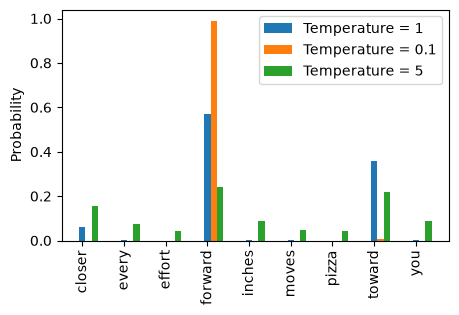

In [85]:
# 온도 스케일링(temperature scaling)
# 온도 스케일링은 로짓을 0보다 큰 수로 나누는 방법
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# 이해하기 쉽도록 원본 확률 분포와 여러 개의 온도 값으로 스케일을 조정한 분포를 나란히 그려 보자
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

import matplotlib.pyplot as plt
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout
plt.show()

In [86]:
# 탑-k 방식을 코드로 구현
# 먼저 가장 큰 로짓 값을 가진 토큰을 선택
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
# torch.return_types.topk(
# values=tensor([6.7500, 6.2800, 4.5100]),
# indices=tensor([3, 7, 0]))
print(f"탑-k 로짓: {top_logits}")
print(f"탑-k 위치: {top_pos}")

# 다음으로 파이토치의 where 함수를 사용해 탑-k 토큰 중에서 가장 마지막 토큰보다 작은 로짓 값을 가진 모든 토큰의 로짓 값을 음의 무한대(-inf)로 지정
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(f"new_logits: {new_logits}")

# 마지막으로 softmax 함수를 적용하여 이를 다음 토큰 확률로 바꾼다
topk_probas = torch.softmax(new_logits, dim=0)
print(f"topk_probas: {topk_probas}")

탑-k 로짓: tensor([6.7500, 6.2800, 4.5100])
탑-k 위치: tensor([3, 7, 0])
new_logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
topk_probas: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [ ]:
# 코드 5-4 다양성을 증가시키기 위해 수정된 텍스트 생성 함수
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)

            logits = torch.where(
                condition=logits < min_val,
                input=torch.tensor(float('-inf')).to(logits.device),
                other=logits
            )

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx

In [104]:
# 새로운 generate 함수를 테스트
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print(f"출력 텍스트:\n{token_ids_to_text(token_ids, tokenizer)}")

출력 텍스트:
Every effort moves you stand to work on surprise, a one of us had gone with random-
